<a href="https://colab.research.google.com/github/swirita/salmonellosis-forecasting-analysis/blob/main/notebooks/02_salmonellosis_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Salmonellosis Analysis

It answers four practical questions:

1. How much change in reported cases overtime
2. which season of the year do the cases spike?
3. Which states have the highest reported case rates?

It also checks for repeating **weekly** and **monthly** seasonal patterns.



In [ ]:
# Imports
import os
from datetime import date, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display
from statsmodels.tsa.seasonal import seasonal_decompose


## Custom Functions

In [ ]:
# Default visual style

# Palette sampled from the salmonellosis banner
NAVY = "#252653"
BLUE = "#5368A6"
PURPLE = "#8B6DB5"
CYAN = "#68B8C4"
LAVENDER = "#D2BCE8"
SLATE = "#8D95A9"
LIGHT_GRAY = "#E7E9F0"
TEXT_GRAY = "#555B70"

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (12, 6),
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.facecolor": "white",
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.titlecolor": NAVY,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.labelcolor": TEXT_GRAY,
    "axes.labelsize": 11,
    "xtick.color": TEXT_GRAY,
    "ytick.color": TEXT_GRAY,
    "grid.color": LIGHT_GRAY,
    "grid.linewidth": 0.8,
    "axes.prop_cycle": plt.cycler(color=[NAVY, PURPLE, CYAN, BLUE, SLATE]),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "sans-serif",
})

# Apply the same finishing style to each chart.
def format_chart(ax, y_label="Reported cases"):
    ax.set_xlabel("")
    ax.set_ylabel(y_label)
    ax.yaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}"))
    ax.grid(axis="x", visible=False)
    ax.margins(x=0.01)

## Load and Prepare Data

In [ ]:
# Connect Google Colab to Google Drive
from google.colab import drive
drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
# Project folders
project_folder = "/content/drive/MyDrive/Salmonellosis Forecasting and Analysis"
data_folder = os.path.join(project_folder, "data")

# Load the cleaned data created in the preparation notebook
cleaned_file_path = os.path.join(data_folder, "salmonellosis_weekly_cleaned.csv")
df = pd.read_csv(cleaned_file_path)

print(f"Data loaded: {df.shape[0]:,} rows and {df.shape[1]} columns")
display(df.head())


Data loaded: 17,079 rows and 10 columns


,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
0,ALABAMA,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,10,38.0,10,6.0,Winter,2.0
1,ALABAMA,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,3,38.0,18,12.0,Winter,10.0
2,ALABAMA,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,24,17.0,Winter,3.0
3,ALABAMA,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,2,38.0,26,25.0,Winter,0.0
4,ALABAMA,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,0,38.0,29,30.0,Winter,2.0


In [ ]:
# Select the national weekly totals
national = df[
    df["Reporting Area"] == "US RESIDENTS"
].copy()

# Arrange the observations correctly
national = national.sort_values(
    ["Current MMWR Year", "MMWR WEEK"]
)

# Create one weekly date for every observation
national["Date"] = pd.date_range(
    start="2022-01-08",
    periods=len(national),
    freq="W-SAT"
)

# Use Date as the index
national = national.set_index("Date")

national.head()

,Reporting Area,Current MMWR Year,MMWR WEEK,Label,Current week,Previous 52 week Max,Cumulative YTD Current MMWR Year,Cumulative YTD Previous MMWR Year,Season,Previous week cases
Date,,,,,,,,,,
2022-01-08,US RESIDENTS,2022,1,Salmonellosis (excluding Salmonella Typhi infe...,96,1212.0,96,333.0,Winter,2.0
2022-01-15,US RESIDENTS,2022,2,Salmonellosis (excluding Salmonella Typhi infe...,77,1217.0,415,677.0,Winter,96.0
2022-01-22,US RESIDENTS,2022,3,Salmonellosis (excluding Salmonella Typhi infe...,24,1217.0,535,1016.0,Winter,77.0
2022-01-29,US RESIDENTS,2022,4,Salmonellosis (excluding Salmonella Typhi infe...,46,1217.0,663,1387.0,Winter,24.0
2022-02-05,US RESIDENTS,2022,5,Salmonellosis (excluding Salmonella Typhi infe...,65,1227.0,977,1699.0,Winter,46.0


## 1. Reported Cases overtime in US



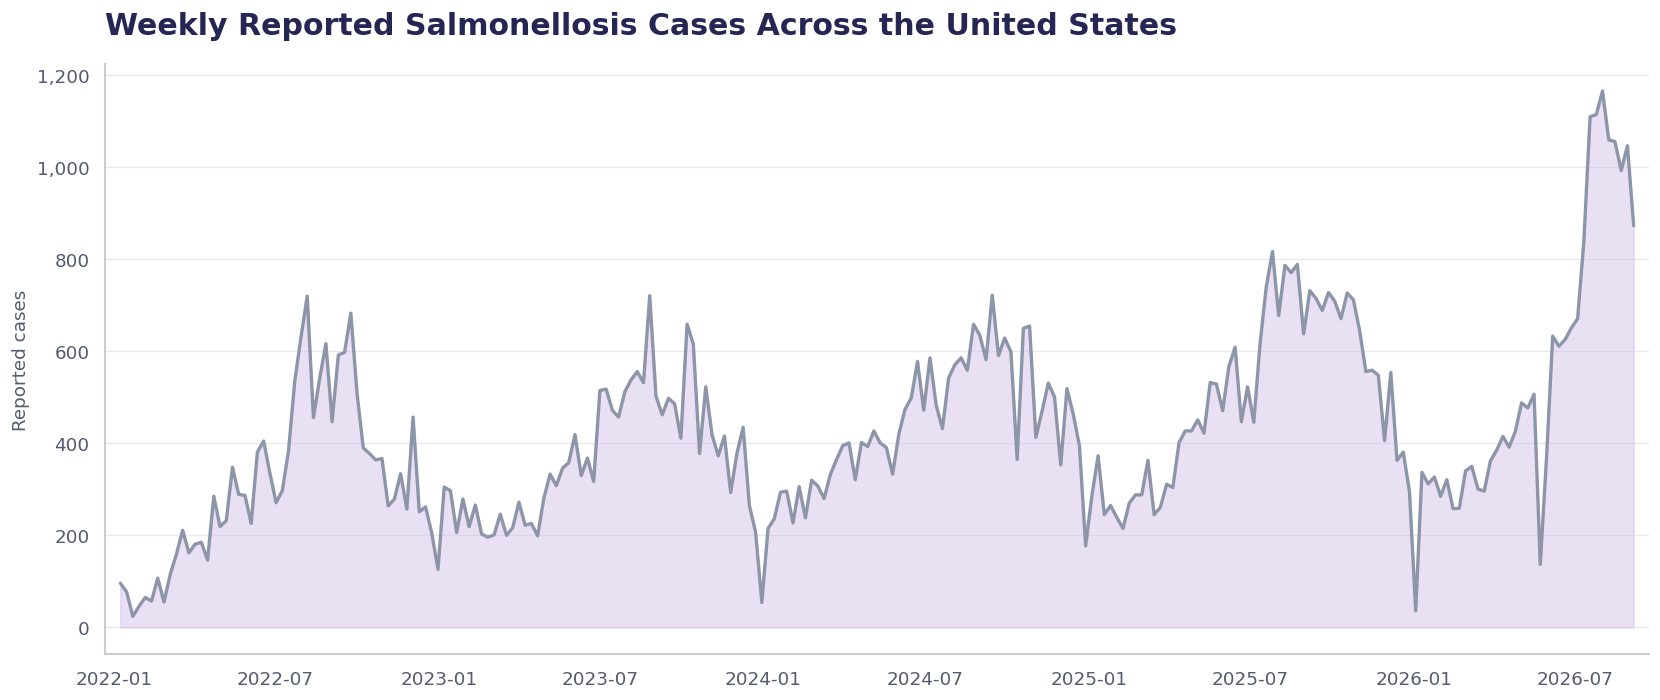

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))

# Plot weekly cases
ax.plot(
    national.index,
    national["Current week"],
    color=SLATE,
    linewidth=2
)

ax.fill_between(
    national.index,
    national["Current week"],
    color=LAVENDER,
    alpha=0.45
)

ax.set_title(
    "Weekly Reported Salmonellosis Cases Across the United States",
    loc="left",
    pad=18
)

format_chart(ax)

fig.tight_layout()

## 2. When during the year do cases spike?


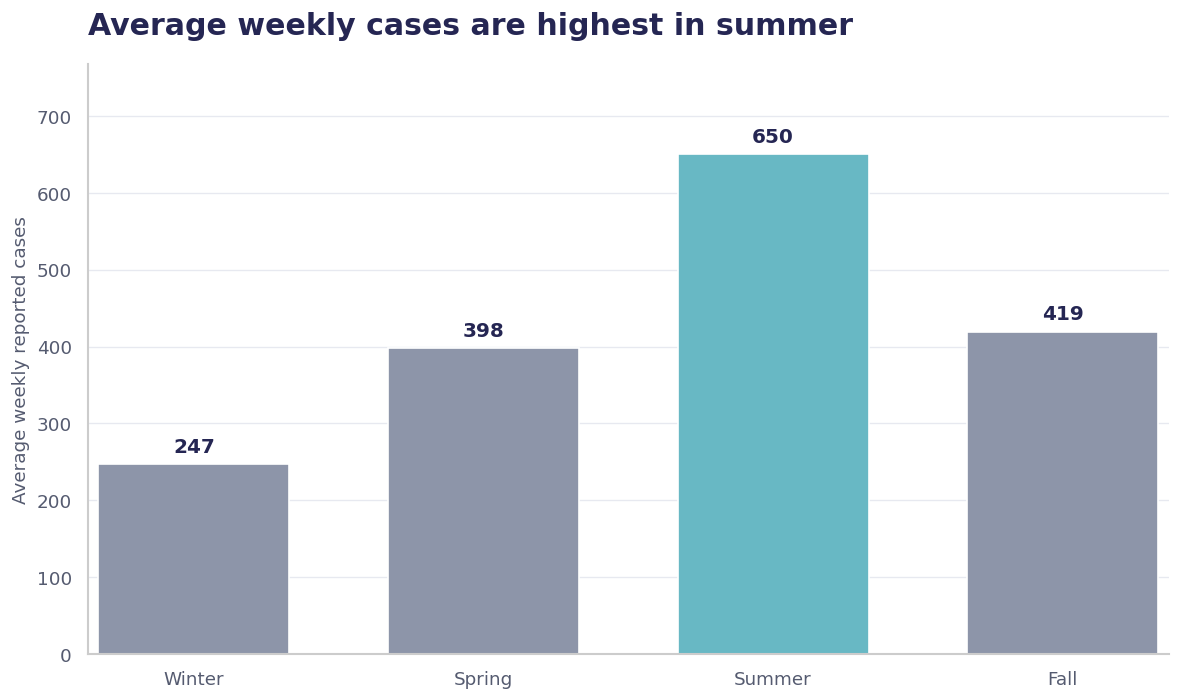

What this means: Summer had the highest weekly average (650 cases), compared with 247 in Winter.


In [ ]:
season_order = ["Winter", "Spring", "Summer", "Fall"]

season_average = (
    national.groupby("Season")["Current week"]
    .mean()
    .reindex(season_order)
)

highest_season = season_average.idxmax()
bar_colors = [CYAN if season == highest_season else SLATE for season in season_order]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    season_average.index,
    season_average.values,
    color=bar_colors,
    width=0.66,
)

ax.bar_label(
    bars,
    labels=[f"{value:,.0f}" for value in season_average.values],
    padding=5,
    color=NAVY,
    fontweight="bold",
)

ax.set_title("Average weekly cases are highest in " + highest_season.lower(), loc="left", pad=18)

format_chart(ax, y_label="Average weekly reported cases")
ax.set_ylim(0, season_average.max() * 1.18)

fig.tight_layout()
plt.show()

lowest_season = season_average.idxmin()
print(
    f"What this means: {highest_season} had the highest weekly average "
    f"({season_average[highest_season]:,.0f} cases), compared with "
    f"{season_average[lowest_season]:,.0f} in {lowest_season}."
)


## Which states have the highest reported case rates?


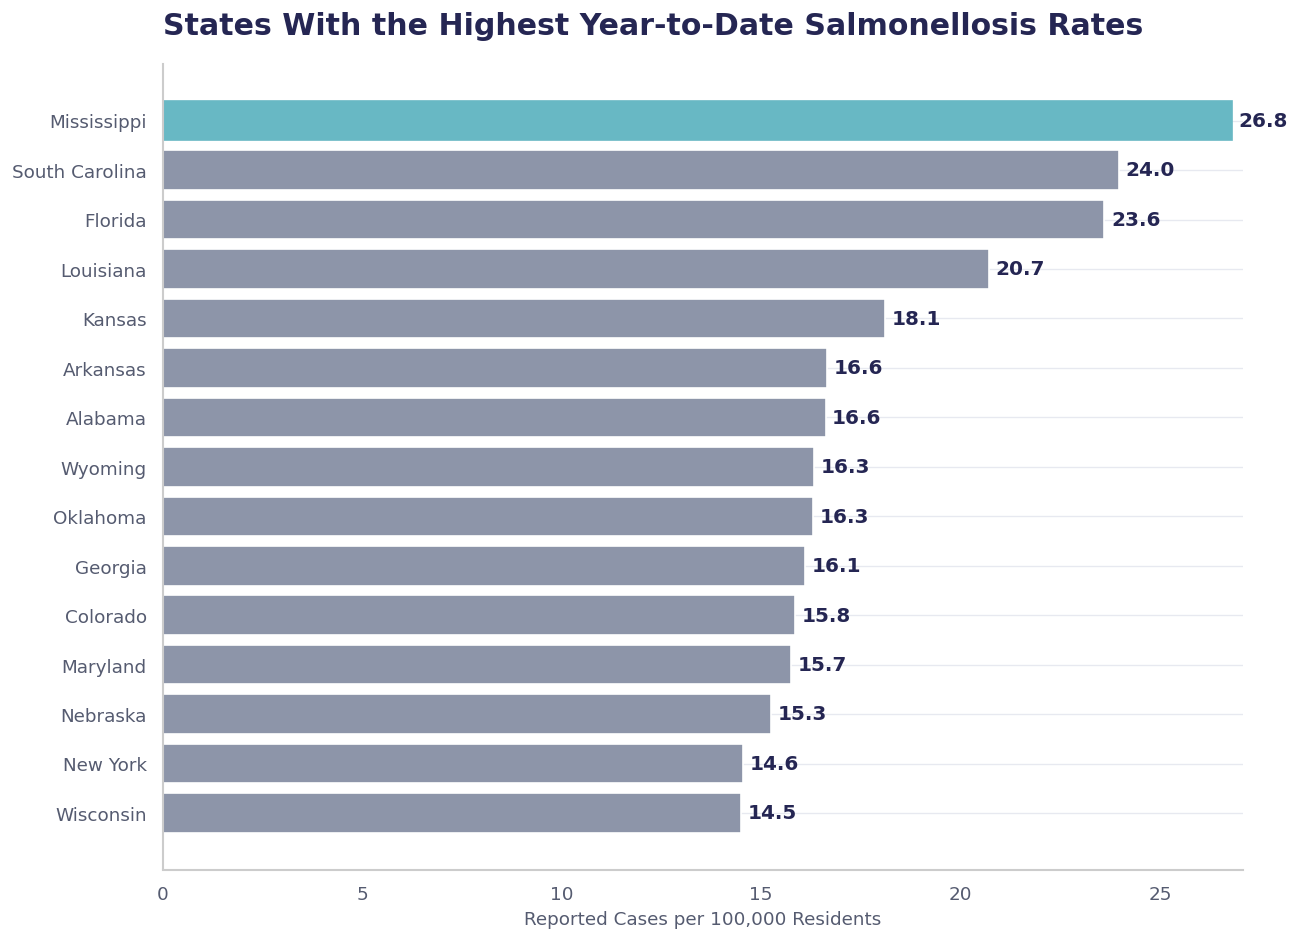

Mississippi had the highest reported rate, with 26.8 cases per 100,000 residents through week 35 of 2026.


In [ ]:
# Find the latest available year
latest_year = df["Current MMWR Year"].max()

# Find the latest available week in that year
latest_week = df.loc[
    df["Current MMWR Year"] == latest_year,
    "MMWR WEEK"
].max()


# Keep data from the latest available week
latest_areas = df[
    (df["Current MMWR Year"] == latest_year)
    & (df["MMWR WEEK"] == latest_week)
].copy()


# Standardize area names
latest_areas["Reporting Area"] = (
    latest_areas["Reporting Area"]
    .str.upper()
    .str.strip()
)

# Combine New York City and Upstate New York
latest_areas["Reporting Area"] = latest_areas["Reporting Area"].replace({
    "NEW YORK CITY": "NEW YORK",
    "UPSTATE NEW YORK": "NEW YORK"
})


# Calculate one year-to-date total for each state
latest_areas = (
    latest_areas
    .groupby("Reporting Area", as_index=False)[
        "Cumulative YTD Current MMWR Year"
    ]
    .sum()
)


# Load 2024 state population estimates from the US Census Bureau
population_url = (
    "https://www2.census.gov/programs-surveys/popest/"
    "datasets/2020-2024/state/totals/"
    "NST-EST2024-ALLDATA.csv"
)

population = pd.read_csv(population_url)

# Ensure SUMLEV is numeric
population["SUMLEV"] = pd.to_numeric(
    population["SUMLEV"],
    errors="coerce"
)

# Keep state-level population estimates
population = population.loc[
    population["SUMLEV"] == 40,
    ["NAME", "POPESTIMATE2024"]
].copy()

population.columns = [
    "Reporting Area",
    "Population"
]

# Standardize state names
population["Reporting Area"] = (
    population["Reporting Area"]
    .str.upper()
    .str.strip()
)


# Merge the reported cases with population estimates
state_rates = latest_areas.merge(
    population,
    on="Reporting Area",
    how="inner"
)


# Calculate year-to-date cases per 100,000 residents
state_rates["Cases per 100,000"] = (
    state_rates["Cumulative YTD Current MMWR Year"]
    / state_rates["Population"]
    * 100_000
)


# Select the 15 states with the highest rates
top_15_rates = (
    state_rates
    .sort_values(
        "Cases per 100,000",
        ascending=False
    )
    .head(15)
    .reset_index(drop=True)
)


# Create positions for the bars
y_positions = np.arange(len(top_15_rates))

fig, ax = plt.subplots(figsize=(11, 8))

bars = ax.barh(
    y_positions,
    top_15_rates["Cases per 100,000"],
    color=SLATE,
    height=0.8
)

# Highlight the state with the highest rate
bars[0].set_color(CYAN)

# Add rate labels
ax.bar_label(
    bars,
    labels=[
        f"{rate:.1f}"
        for rate in top_15_rates["Cases per 100,000"]
    ],
    padding=4,
    color=NAVY,
    fontweight="bold"
)

ax.set_title(
    "States With the Highest Year-to-Date Salmonellosis Rates",
    loc="left",
    pad=18
)

# Apply the general chart formatting first
format_chart(ax)

# Add state names after format_chart()
ax.set_yticks(y_positions)

ax.set_yticklabels(
    top_15_rates["Reporting Area"].str.title()
)

# Put the highest-rate state at the top
ax.invert_yaxis()

ax.set_xlabel("Reported Cases per 100,000 Residents")
ax.set_ylabel("")

plt.tight_layout()
plt.show()


# Print the main finding
top_state = top_15_rates.iloc[0]

print(
    f"{top_state['Reporting Area'].title()} had the highest reported rate, "
    f"with {top_state['Cases per 100,000']:.1f} cases per 100,000 residents "
    f"through week {latest_week:.0f} of {latest_year:.0f}."
)


## Seasonality check

- **Weekly view:** checks for a pattern that repeats about every 52 weeks.
- **Monthly view:** checks for a pattern that repeats every 12 months.


### Yearly seasonality

The national series is placed on a regular Saturday frequency. Any missing week is filled by a straight line between its neighboring weeks so `seasonal_decompose()` receives a complete, evenly spaced series.


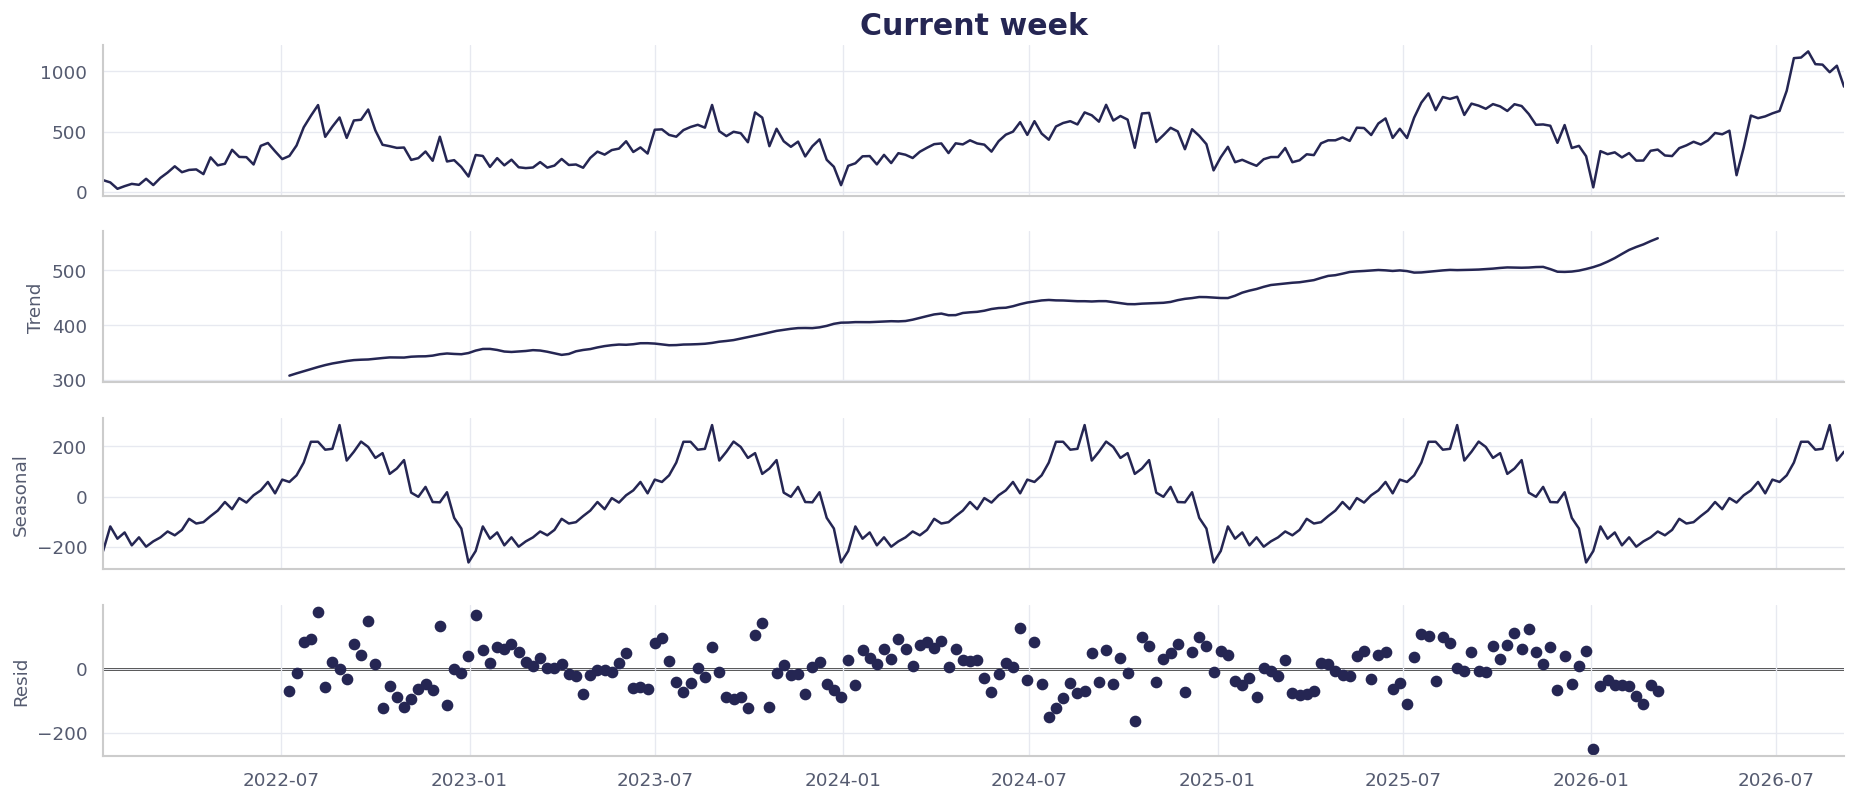

In [ ]:
# Create a regular weekly time series
weekly_cases = national["Current week"].asfreq("W-SAT")

# Fill any missing weeks
weekly_cases = weekly_cases.interpolate()

# We see a repeating pattern that is likely seasonal
# Apply seasonal decomposition
decomp = seasonal_decompose(weekly_cases)
fig = decomp.plot()
fig.set_size_inches(16, 7)

In [ ]:
seasonal_part = decomp.seasonal

peak_week = seasonal_part.idxmax().isocalendar().week
lowest_week = seasonal_part.idxmin().isocalendar().week
seasonal_difference = seasonal_part.max() - seasonal_part.min()

print(
    f"The yearly pattern is highest around week {peak_week} "
    f"and lowest around week {lowest_week}. "
    f"The seasonal difference is approximately "
    f"{seasonal_difference:,.0f} cases."
)

The yearly pattern is highest around week 34 and lowest around week 52. The seasonal difference is approximately 549 cases.


### Yearly seasonality (months)

Weekly counts are added within each calendar month. Incomplete months are removed so a partial month is not mistaken for a real decline.


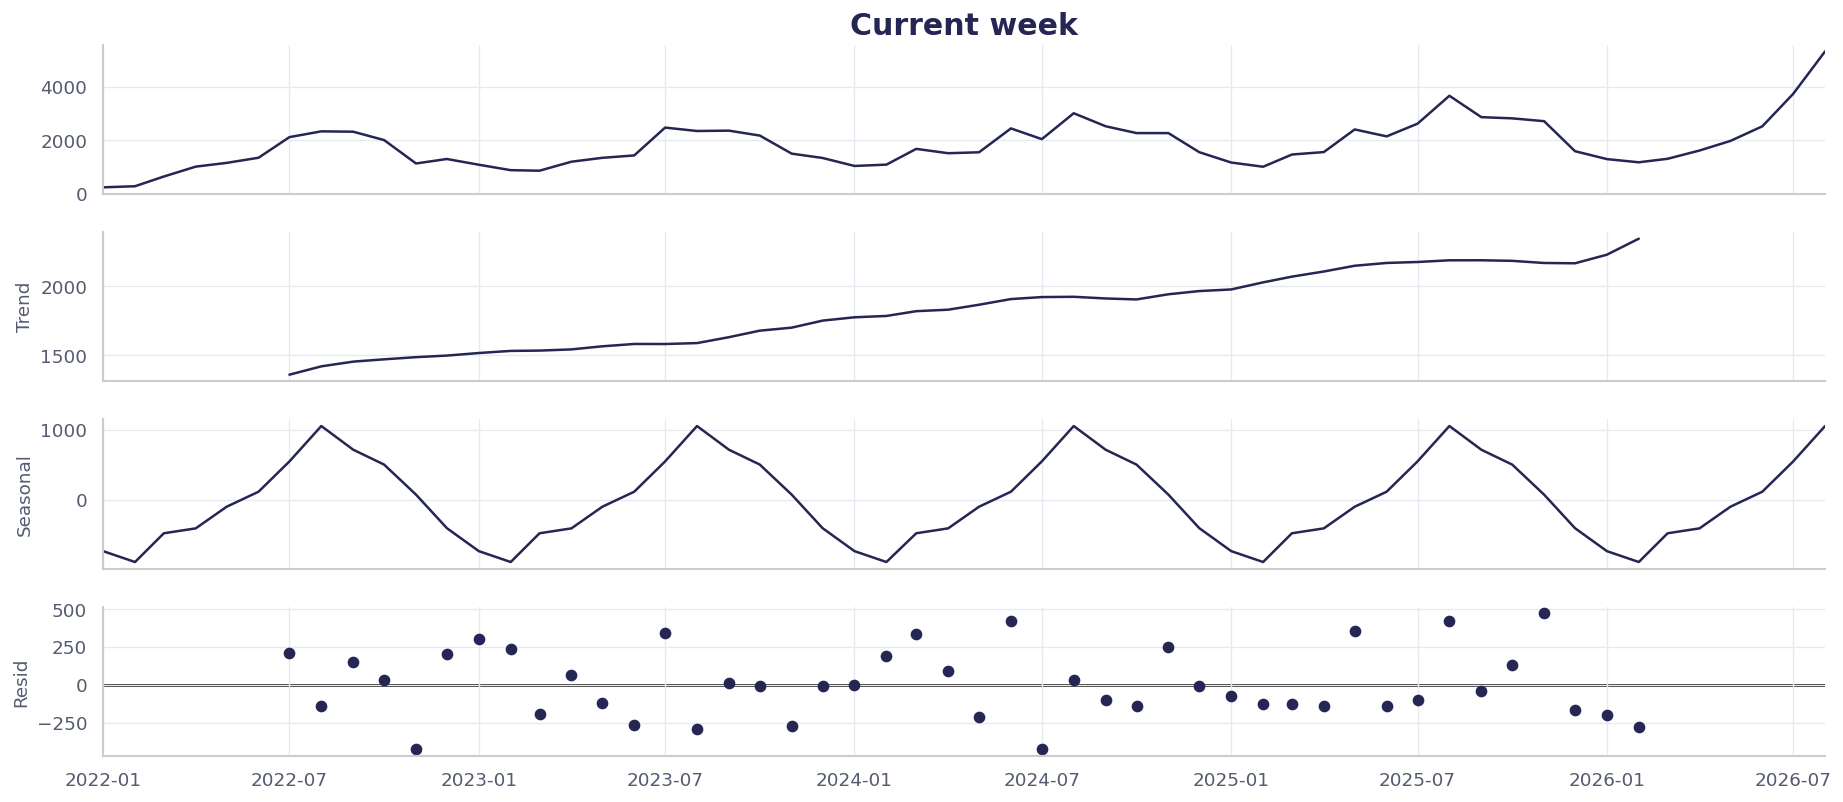

In [ ]:
# Calculate monthly reported cases
monthly_cases = weekly_cases.resample("MS").sum()

# Remove the final month if it is incomplete
weeks_per_month = weekly_cases.resample("MS").count()
monthly_cases = monthly_cases[weeks_per_month >= 4]

decomp = seasonal_decompose(monthly_cases)
fig = decomp.plot()
fig.set_size_inches(16, 7)

In [ ]:
monthly_seasonal_part = decomp.seasonal

peak_month = monthly_seasonal_part.idxmax().strftime("%B")
lowest_month = monthly_seasonal_part.idxmin().strftime("%B")

monthly_difference = (
    monthly_seasonal_part.max()
    - monthly_seasonal_part.min()
)

print(
    f"The yearly pattern is highest in {peak_month} "
    f"and lowest in {lowest_month}. "
    f"The seasonal difference is approximately "
    f"{monthly_difference:,.0f} cases."
)

The yearly pattern is highest in August and lowest in February. The seasonal difference is approximately 1,939 cases.
